# SINE WAVE MODEL
This script is to develop a model to predict the sine of a value. The model is deployed to a stm32 board (nucleo-l476rg). The model is converted to a tflite model to be run with the tensorflowlite-micro tflm frame work.

## Importing the needed library

In [1]:
import os

from utils import *
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

from models.Autoencoder import Conv1DDenoiser

2025-10-06 08:35:23.865119: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Generating the dataset
The data will contain numbers between 0 and 2pi, the sine function will be defined in rad.
A random uniform error is added to the sine values to give the dataset a bit of variability and see how the model will perform.
The error is centred with a mean of 0 and std 0f 0.1. This is chosen such that 95% of the error is -0.2 and 0.+2.

In [2]:
train_samples = 500
test_samples = 300
val_samples = 100
# Generate data
x_train, s_train = generate_data(num_samples=train_samples)
x_test, s_test = generate_data(num_samples=test_samples)

x_validate, s_validate = generate_data(num_samples=val_samples)

In [3]:
x_train.shape

(500,)

In [4]:
x_train = x_train.reshape(1, train_samples, 1)
s_train = s_train.reshape(1, train_samples, 1)
x_test = x_test.reshape(1, test_samples, 1)
s_test = s_test.reshape(1, test_samples, 1)

x_validate = x_validate.reshape(1, val_samples, 1)
s_validate = s_validate.reshape(1, val_samples, 1)




In [5]:
x_train.shape

(1, 500, 1)

In [6]:
model_name = "conv_downsize"

In [ ]:
if model_name == "autoencoder_filter":
    model = Conv1DDenoiser()
    dummy_input = tf.random.normal([1, 1024, 1])  
    output = model(dummy_input)
    print(output.shape)
elif model_name == "neural_filter":
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="relu", input_shape=(1,)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1)
    ])
elif model_name == "adaptive_neural":
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="relu", input_shape=(1,)),
        tf.keras.layers.Conv1D(16, kernel_size=9, padding='same'),
        tf.keras.layers.Dense(1)
    ])
elif model_name == "conv1_no_array":
    model = tf.keras.Sequential([
            tf.keras.layers.Conv1D(16, kernel_size=9, padding='same', activation="relu", input_shape=(1000, 1)),
            tf.keras.layers.Conv1D(32, kernel_size=5, padding='same', activation="relu"),
            tf.keras.layers.Dense(1)
        ])
elif model_name == "conv_downsize":
    model = tf.keras.Sequential([
            tf.keras.layers.Conv1D(16, kernel_size=5, padding='same', activation="relu", input_shape=(500, 1)),
            Dense(1)
        ])
else:
    # Build the neural network
    model = Sequential([
        Dense(64, activation='relu', input_shape=(1,)),
        Dense(64, activation='relu'),
        Dense(1)
    ])

/home/sergiusz/ML_Filter/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-06 08:35:54.076309: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-10-06 08:35:54.076338: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
2025-10-06 08:35:54.076342: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2025-10-06 08:35:54.076346: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is di

In [65]:
dummy_input[0][1][0]

NameError: name 'dummy_input' is not defined

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 500, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500, 1)         │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113 (452.00 B)

 Trainable params: 113 (452.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=["mae"])

# Train the model
history = model.fit(x_train, s_train, epochs=200, batch_size=32, validation_data=(x_validate, s_validate))

# Evaluate the model
loss = model.evaluate(x_test, s_test)
print(f"Test Loss: {loss}")

s_pred = model.predict(x_test)




Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step - loss: 0.6576 - mae: 0.7228 - val_loss: 0.6107 - val_mae: 0.6985
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.6398 - mae: 0.7130 - val_loss: 0.5950 - val_mae: 0.6892
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.6224 - mae: 0.7033 - val_loss: 0.5795 - val_mae: 0.6800
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.6052 - mae: 0.6936 - val_loss: 0.5644 - val_mae: 0.6708
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.5883 - mae: 0.6838 - val_loss: 0.5496 - val_mae: 0.6617
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.5718 - mae: 0.6741 - val_loss: 0.5350 - val_mae: 0.6527
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.5555 - mae: 0.6645 - val_loss: 0.5208 - val_mae: 0.6437
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.5395 - mae: 0.6548 - val_loss: 0.5067 - val_mae: 0.6349
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.5238 - mae:

# Training Results

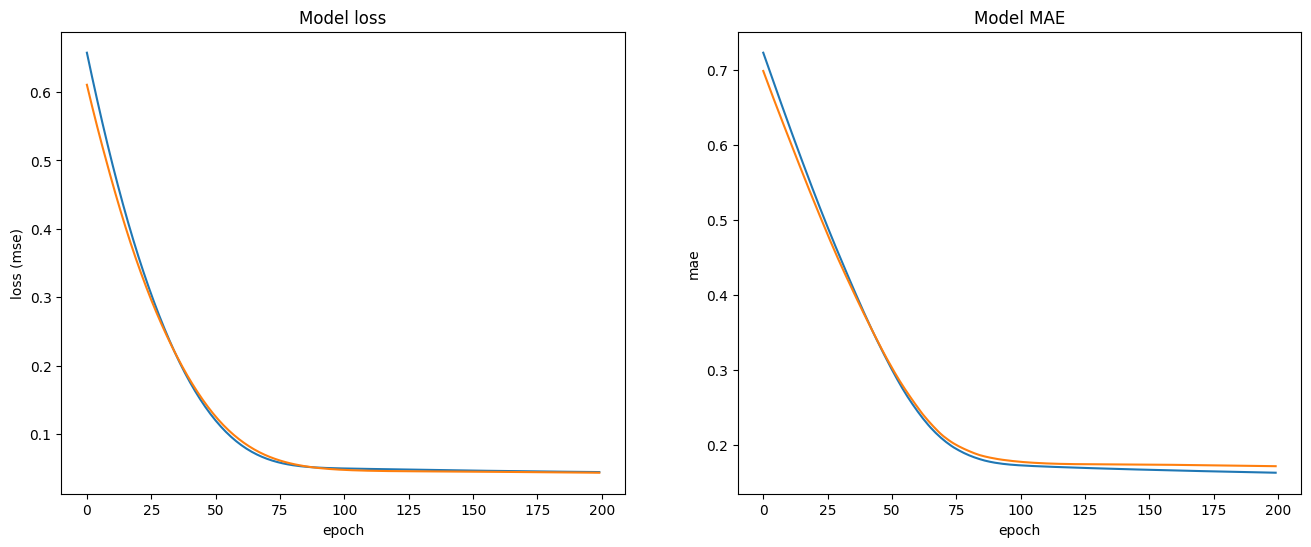

In [10]:
fig, axes = plt.subplots( 1, 2, figsize=(16,6))

axes[0].plot(history.history["loss"], label="training_loss")
axes[0].plot(history.history["val_loss"], label="validation_loss")
axes[0].set_title("Model loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss (mse)")

axes[1].plot(history.history["mae"], label="training_mae")
axes[1].plot(history.history["val_mae"], label="validation_loss")
axes[1].set_title("Model MAE")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("mae")

plt.savefig(f'results/{model_name}_training.png')
plt.show()

# For scalar input

ValueError: x and y can be no greater than 2D, but have shapes (1,) and (1, 300, 1)

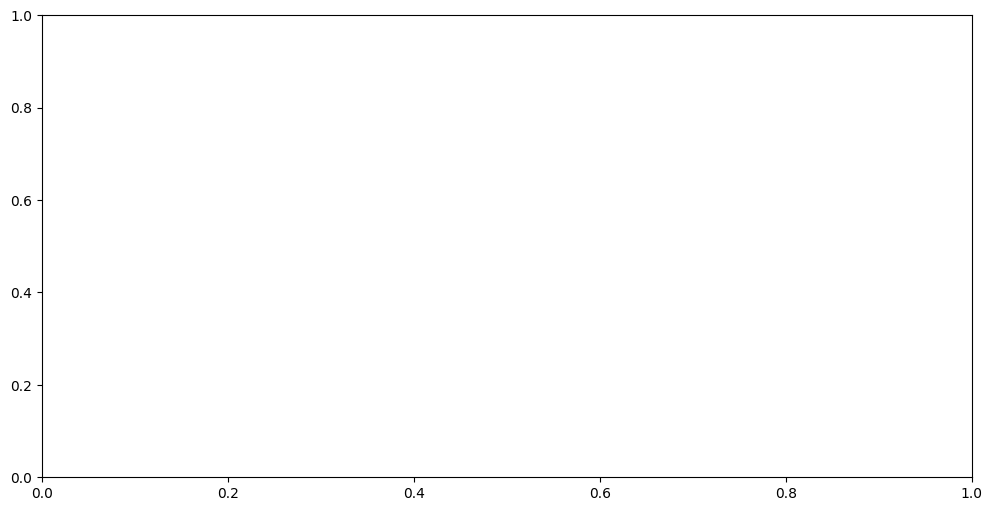

In [133]:
plt.figure(figsize=(12, 6))
plt.plot(x_test, label='Noisy Signal')
plt.plot(s_test, label='Clean Signal')
plt.plot(s_pred, label='Predicted Clean Signal', linestyle='dashed')
plt.legend()
plt.savefig(f'results/{model_name}.png')

## For array input

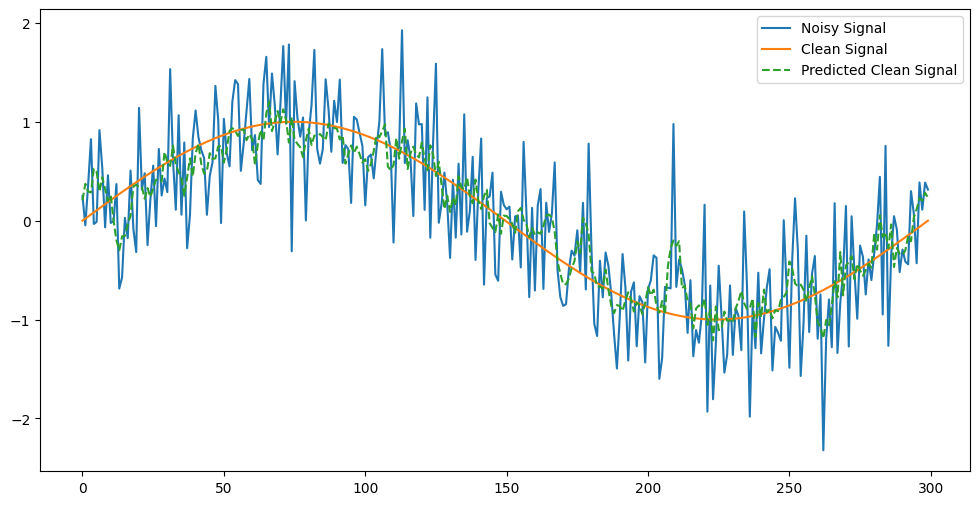

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(x_test[0], label='Noisy Signal')
plt.plot(s_test[0], label='Clean Signal')
plt.plot(s_pred[0], label='Predicted Clean Signal', linestyle='dashed')
plt.legend()
plt.savefig(f'results/{model_name}.png')

## Saving the keras model

In [12]:
model.save(f'checkpoints/{model_name}.keras')


In [80]:
#Loading if needed
model = tf.keras.models.load_model(f'checkpoints/{model_name}.keras')
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_24 (Conv1D)              │ (None, 1000, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 1000, 16)       │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1000, 1)        │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,741 (34.15 KB)

 Trainable params: 2,913 (11.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,828 (22.77 KB)

## Converting the model to tflite

In [13]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.optimizations = []
converter.allow_custom_ops = False
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]



# For full integer quantization
def representative_dataset_gen():
  num_calibration_steps = 300
  for _ in range(num_calibration_steps):
    # Get sample input data as a numpy array in a method of your choosing.
    test_data, _ = generate_data(num_calibration_steps)
    test_data.astype(dtype=np.float32)
    yield [test_data]

# Ensure integer input/output
# converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
# converter.inference_input_type = tf.int8
# converter.inference_output_type = tf.int8
# converter.representative_dataset = representative_dataset_gen

tflite_model = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmpojdd2p1d/assets


INFO:tensorflow:Assets written to: /tmp/tmpojdd2p1d/assets


Saved artifact at '/tmp/tmpojdd2p1d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 500, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 500, 1), dtype=tf.float32, name=None)
Captures:
  128092221832384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128092221825344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128092221829568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128092221831328: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1759732595.239574   11813 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1759732595.239586   11813 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-10-06 08:36:35.239776: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpojdd2p1d
2025-10-06 08:36:35.240145: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-10-06 08:36:35.240150: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpojdd2p1d
I0000 00:00:1759732595.242708   11813 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2025-10-06 08:36:35.243117: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-10-06 08:36:35.256428: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpojdd2p1d
2025-10-06 08:36:35.261250: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

In [89]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Only built-in ops, no TF ops
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]

# Optional: quantization to int8 for STM32
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("conv1d_micro.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmpm3nsr9ro/assets


INFO:tensorflow:Assets written to: /tmp/tmpm3nsr9ro/assets


Saved artifact at '/tmp/tmpm3nsr9ro'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1024, 1), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 1024, 1), dtype=tf.float32, name=None)
Captures:
  131799532392288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131799532403728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131799532390352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131799532390704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131799532389296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131799532318640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131799532311248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131799532309488: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1759318462.099958  108484 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1759318462.099975  108484 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-10-01 13:34:22.100176: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpm3nsr9ro
2025-10-01 13:34:22.101109: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-10-01 13:34:22.101119: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpm3nsr9ro
2025-10-01 13:34:22.106853: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-10-01 13:34:22.139025: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpm3nsr9ro
2025-10-01 13:34:22.148521: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 48348 microseconds.


## Converting the model to the c, TFlite micro format for the microcontroller

In [137]:
# Save as .tflite file
with open(f"results/{model_name}.tflite", "wb") as file:
    file.write(tflite_model)

with open(f"{model_name}.tflite", "wb") as file:
    file.write(tflite_model)

# Breaking the byte in several lines to fit better in the c header file
tflite_model_split_line = np.array_split([format(hex_value, '#04x') for hex_value in tflite_model], len(tflite_model)//8)

C_HEADER_DIR = "STM_project"
newline = ",\n    "  # separator to avoid new line character

# Write TfLite model to a C header file
open(f"{C_HEADER_DIR}/{model_name.lower()}.h", "w").write(
f"""
#ifndef {model_name.upper()}_H
#define {model_name.upper()}_H

const unsigned int {model_name.lower()}_len = {len(tflite_model)};

const unsigned char {model_name.lower()}[{len(tflite_model)}] = {{
    {newline.join([", ".join(line) for line in tflite_model_split_line])}
}};

#endif // {model_name.upper()}_H
"""
)


17925

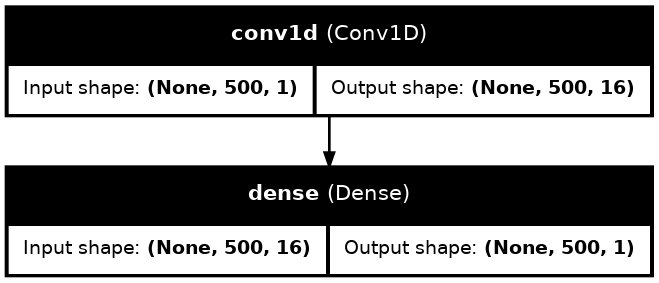

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model,
           to_file='model.png',
           show_shapes=True,
           show_layer_names=True,
           expand_nested=True,   # show inner layers if nested
           dpi=96)
